In [75]:
# Cài thư viện nếu chạy trên Kaggle/Colab
!pip install timm faiss-cpu scikit-learn opencv-python huggingface_hub scipy --quiet

import os
import time
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import timm
import faiss
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter
from sklearn.metrics import roc_auc_score
from torch.utils.data import Dataset, DataLoader
from huggingface_hub import hf_hub_download

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [76]:
CONFIG = {
    "data_path": "/kaggle/input/datasets/ipythonx/mvtec-ad",
    "image_size": 224,

    #"base" hoặc "upgrade"
    "model_version": "base",

    # model_version="base": chọn carpet, grid, leather, tile, wood, bottle, cable, capsule, hazelnut, toothbrush, zipper
    "category": "bottle",

    # Repo theo notebook train base-vision.ipynb
    "hf_repo_id": "Manh2005/base-version",
    "threshold_source": "train_good",
    "threshold_percentile": 99.0,
    # Nếu dùng upgrade, đổi thành:
    # "model_version": "upgrade",
    # "category": "pill",
    # "hf_repo_id": "Manh2005/upgrade-version",
}

BASE_CATEGORIES = [
    "carpet", "grid", "leather", "tile", "wood",
    "bottle", "cable", "capsule", "hazelnut", "toothbrush", "zipper"
]

UPGRADE_CATEGORIES = [
    "carpet", "grid", "leather", "tile", "wood",
    "bottle", "cable", "capsule", "hazelnut", "metal_nut",
    "pill", "screw", "toothbrush", "transistor", "zipper"
]

if CONFIG["model_version"] == "base" and CONFIG["category"] not in BASE_CATEGORIES:
    raise ValueError(f"Bản base không có category {CONFIG['category']}. Hãy đổi category hoặc dùng model_version='upgrade'.")

if CONFIG["model_version"] == "upgrade" and CONFIG["category"] not in UPGRADE_CATEGORIES:
    raise ValueError(f"Bản upgrade không có category {CONFIG['category']}.")

print(CONFIG)

{'data_path': '/kaggle/input/datasets/ipythonx/mvtec-ad', 'image_size': 224, 'model_version': 'base', 'category': 'bottle', 'hf_repo_id': 'Manh2005/base-version', 'threshold_source': 'train_good', 'threshold_percentile': 99.0}


In [77]:
# Transform cần khớp với notebook train: Resize 256 -> CenterCrop 224 -> Normalize
vis_transform = T.Compose([
    T.Resize((256, 256)),
    T.CenterCrop((224, 224)),
])

transform = T.Compose([
    T.Resize((256, 256)),
    T.CenterCrop((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

mask_transform = T.Compose([
    T.Resize((256, 256), interpolation=T.InterpolationMode.NEAREST),
    T.CenterCrop((224, 224)),
    T.ToTensor(),
])

In [78]:
class BaseExtractor(nn.Module):
    """Khớp với base-vision.ipynb: Swin Base, hook 1 block, feature dim thường là 512."""
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "swin_base_patch4_window7_224",
            pretrained=True,
            num_classes=2
        )
        self._register_hooks()

    def _register_hooks(self):
        def hook_fn(module, input, output):
            module.extracted_feature = output
        self.backbone.layers[2].blocks[3].register_forward_hook(hook_fn)

    def forward_features(self, x):
        _ = self.backbone.forward_features(x)
        feat = self.backbone.layers[2].blocks[3].extracted_feature
        return feat.permute(0, 3, 1, 2)

    def forward_classifier(self, x):
        return self.backbone(x)

    def forward(self, x):
        return self.forward_features(x)
class UpgradeExtractor(nn.Module):
    """Khớp với upgrade-version-ipynb.ipynb: Swin Base, hook 2 block, concat feature, feature dim thường là 1024."""
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "swin_base_patch4_window7_224",
            pretrained=True,
            num_classes=2
        )
        self.avg_pool = nn.AvgPool2d(kernel_size=3, stride=1, padding=1)
        self._register_hooks()

    def _register_hooks(self):
        def hook_fn(module, input, output):
            module.extracted_feature = output
        self.backbone.layers[2].blocks[2].register_forward_hook(hook_fn)
        self.backbone.layers[2].blocks[3].register_forward_hook(hook_fn)

    def forward_features(self, x):
        _ = self.backbone.forward_features(x)
        feat3 = self.backbone.layers[2].blocks[2].extracted_feature
        feat4 = self.backbone.layers[2].blocks[3].extracted_feature
        block3 = feat3.permute(0, 3, 1, 2)
        block4 = feat4.permute(0, 3, 1, 2)
        return torch.cat([block3, self.avg_pool(block4)], dim=1)

    def forward_classifier(self, x):
        return self.backbone(x)

    def forward(self, x):
        return self.forward_features(x)
def build_model():
    if CONFIG["model_version"] == "base":
        return BaseExtractor()
    if CONFIG["model_version"] == "upgrade":
        return UpgradeExtractor()
    raise ValueError("model_version phải là 'base' hoặc 'upgrade'.")

In [79]:
def download_model_file(repo_id, category, basename):
    # Notebook train base upload vào subfolder category/
    # Hàm này thử cả category/basename và basename để linh hoạt.
    candidates = [f"{category}/{basename}", basename]
    last_error = None

    for filename in candidates:
        try:
            path = hf_hub_download(repo_id=repo_id, filename=filename)
            print(f"Downloaded: {filename}")
            return path
        except Exception as e:
            last_error = e

    raise RuntimeError(
        f"Không tải được {basename}. Đã thử: {candidates}. "
        f"Kiểm tra repo_id, category, quyền truy cập, và cách upload file lên Hugging Face."
    ) from last_error


category = CONFIG["category"]
model_name = f"vit_core_swin_{category}.pth"
index_name = f"memory_bank_{category}.index"
model_path = download_model_file(CONFIG["hf_repo_id"], category, model_name)
index_path = download_model_file(CONFIG["hf_repo_id"], category, index_name)

extractor = build_model().to(device)
state = torch.load(model_path, map_location=device)
extractor.load_state_dict(state, strict=True)
extractor.eval()

index = faiss.read_index(index_path)

# Kiểm tra logic rất quan trọng: feature dimension phải bằng FAISS index dimension
with torch.no_grad():
    dummy = torch.zeros(1, 3, 224, 224).to(device)
    feat = extractor.forward_features(dummy)
    feature_dim = feat.shape[1]

print("Feature shape:", tuple(feat.shape))
print("FAISS index dim:", index.d)
print("FAISS index total vectors:", index.ntotal)
if feature_dim != index.d:
    raise ValueError(
        f"Dimension mismatch: model trả feature_dim={feature_dim}, nhưng FAISS index.d={index.d}. "
        "Nguyên nhân thường là dùng sai kiến trúc model so với lúc train."
    )

print("Nạp model và FAISS index thành công.")

Downloaded: bottle/vit_core_swin_bottle.pth
Downloaded: bottle/memory_bank_bottle.index
Feature shape: (1, 512, 14, 14)
FAISS index dim: 512
FAISS index total vectors: 4096
Nạp model và FAISS index thành công.


In [80]:
def calculate_anomaly_scores(features, memory_bank_index, k=9):
    B, C, H, W = features.shape
    patches = features.view(B, C, H * W).permute(0, 2, 1).reshape(-1, C)
    patches = patches.detach().cpu().numpy().astype(np.float32)

    k = min(k, memory_bank_index.ntotal)
    distances, _ = memory_bank_index.search(patches, k)

    # FAISS IndexFlatL2 trả về squared L2 distance, cần sqrt.
    distances = np.maximum(distances, 0)
    distances = np.sqrt(distances)

    distances_tensor = torch.tensor(distances, dtype=torch.float32)

    # Softmax theo k-nearest neighbors cho từng patch, không softmax toàn bản đồ H*W.
    softmax_weights = F.softmax(distances_tensor, dim=1)
    base_scores = distances_tensor[:, 0]
    weights = 1.0 - softmax_weights[:, 0]

    anomaly_flat = base_scores * weights
    anomaly_scores = anomaly_flat.view(B, H * W)

    image_scores = anomaly_scores.max(dim=1)[0].numpy()
    patch_scores = anomaly_scores.view(B, H, W).numpy()

    return image_scores, patch_scores

In [81]:
def list_good_images(root_dir, category, source="train_good"):
    """
    source="train_good": lấy ảnh bình thường từ train/good để đặt threshold.
    source="test_good": lấy ảnh bình thường từ test/good, chỉ nên dùng để demo nhanh.
    """
    if source == "train_good":
        good_dir = os.path.join(root_dir, category, "train", "good")
    elif source == "test_good":
        good_dir = os.path.join(root_dir, category, "test", "good")
    else:
        raise ValueError("source phải là 'train_good' hoặc 'test_good'.")

    if not os.path.isdir(good_dir):
        raise FileNotFoundError(f"Không tìm thấy thư mục ảnh good: {good_dir}")

    image_paths = [
        os.path.join(good_dir, f)
        for f in sorted(os.listdir(good_dir))
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"))
    ]

    if len(image_paths) == 0:
        raise RuntimeError(f"Không có ảnh good trong thư mục: {good_dir}")

    return image_paths
def infer_image_score(image_path):
    """
    Trả về anomaly score cấp ảnh.
    Score càng cao thì ảnh càng có khả năng bị lỗi.
    """
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    extractor.eval()
    with torch.no_grad():
        features = extractor.forward_features(input_tensor)
        image_scores, patch_scores = calculate_anomaly_scores(features, index, k=9)

    return float(image_scores[0])


def compute_threshold_from_good_set(
    source=None,
    percentile=None,
    max_images=None
):
    """
    Tính threshold từ phân phối anomaly score của ảnh không lỗi.
    threshold = percentile(scores_good)

    Ví dụ:
    - percentile=95: nhạy hơn, dễ báo lỗi hơn nhưng dễ false alarm hơn.
    - percentile=99: cân bằng hơn cho demo/deployment ban đầu.
    - percentile=99.5: chặt hơn, ít báo lỗi nhầm hơn nhưng có thể bỏ sót lỗi nhẹ.
    """
    source = source or CONFIG.get("threshold_source", "train_good")
    percentile = percentile or CONFIG.get("threshold_percentile", 99.0)

    good_paths = list_good_images(CONFIG["data_path"], CONFIG["category"], source=source)

    if max_images is not None:
        good_paths = good_paths[:max_images]

    scores = []
    for i, img_path in enumerate(good_paths, 1):
        score = infer_image_score(img_path)
        scores.append(score)

        if i % 25 == 0 or i == len(good_paths):
            print(f"Đã tính score good: {i}/{len(good_paths)}")

    scores = np.array(scores, dtype=np.float32)
    threshold = float(np.percentile(scores, percentile))
    print("\n THRESHOLD REPORT")
    print(f"Category              : {CONFIG['category']}")
    print(f"Threshold source      : {source}")
    print(f"Số ảnh good dùng       : {len(scores)}")
    print(f"Good score min         : {scores.min():.6f}")
    print(f"Good score mean        : {scores.mean():.6f}")
    print(f"Good score max         : {scores.max():.6f}")
    print(f"Percentile threshold  : P{percentile}")
    print(f"THRESHOLD             : {threshold:.6f}")

    return threshold, scores

Đã tính score good: 25/209
Đã tính score good: 50/209
Đã tính score good: 75/209
Đã tính score good: 100/209
Đã tính score good: 125/209
Đã tính score good: 150/209
Đã tính score good: 175/209
Đã tính score good: 200/209
Đã tính score good: 209/209

 THRESHOLD REPORT
Category              : bottle
Threshold source      : train_good
Số ảnh good dùng       : 209
Good score min         : 10.136133
Good score mean        : 10.659301
Good score max         : 10.984253
Percentile threshold  : P99.0
THRESHOLD             : 10.972923
Sample good path: /kaggle/input/datasets/ipythonx/mvtec-ad/bottle/test/broken_large/006.png
INFERENCE RESULT
Image path : /kaggle/input/datasets/ipythonx/mvtec-ad/bottle/test/broken_large/006.png
Image score: 28.399090
Threshold  : 11.533465
Kết luận   : LỖI


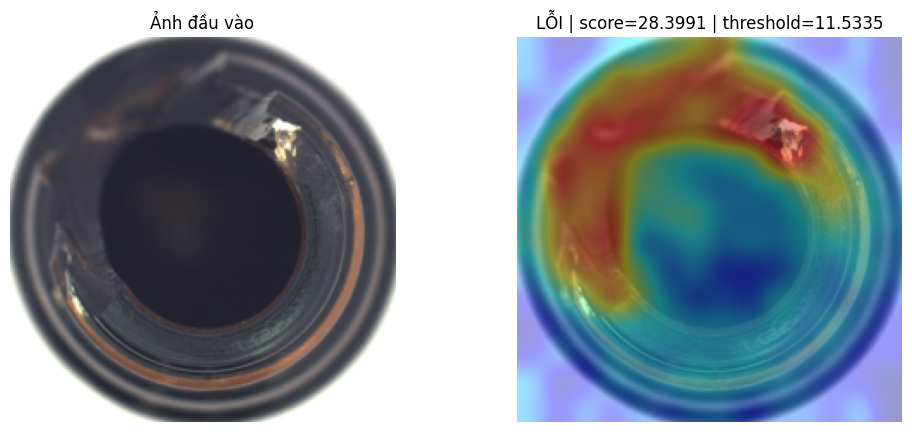

Sample defect path: /kaggle/input/datasets/ipythonx/mvtec-ad/bottle/test/good/003.png
INFERENCE RESULT
Image path : /kaggle/input/datasets/ipythonx/mvtec-ad/bottle/test/good/003.png
Image score: 12.237785
Threshold  : 11.533465
Kết luận   : LỖI


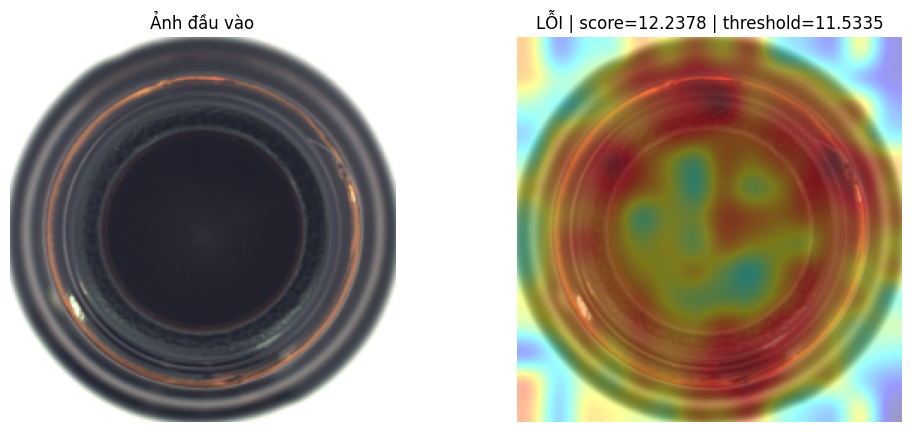

In [82]:
def predict_status(image_score, threshold):
    """
    Quy tắc kết luận:
    - score <= threshold: ảnh bình thường / tốt
    - score > threshold : ảnh lỗi / bất thường
    """
    if image_score > threshold:
        return "LỖI", "Defect Detected"
    return "TỐT", "Good / OK"


def infer_and_visualize(image_path, threshold):
    if threshold is None:
        raise ValueError("Bạn cần truyền threshold. Hãy chạy: THRESHOLD, good_scores = compute_threshold_from_good_set()")

    if not os.path.exists(image_path):
        raise FileNotFoundError(image_path)

    orig_img = Image.open(image_path).convert("RGB")
    vis_img = vis_transform(orig_img)
    input_tensor = transform(orig_img).unsqueeze(0).to(device)

    with torch.no_grad():
        features = extractor.forward_features(input_tensor)
        image_scores, patch_scores = calculate_anomaly_scores(features, index, k=9)

    image_score = float(image_scores[0])
    score_map = cv2.resize(patch_scores[0], (224, 224), interpolation=cv2.INTER_LINEAR)
    score_map = gaussian_filter(score_map, sigma=4)

    eps = 1e-8
    score_norm = (score_map - score_map.min()) / (score_map.max() - score_map.min() + eps)
    score_uint8 = (score_norm * 255).astype(np.uint8)

    heatmap = cv2.applyColorMap(score_uint8, cv2.COLORMAP_JET)
    vis_np = np.array(vis_img)[:, :, ::-1]
    overlay = cv2.addWeighted(vis_np, 0.6, heatmap, 0.4, 0)

    vn_status, en_status = predict_status(image_score, threshold)

    print("INFERENCE RESULT")
    print(f"Image path : {image_path}")
    print(f"Image score: {image_score:.6f}")
    print(f"Threshold  : {threshold:.6f}")
    print(f"Kết luận   : {vn_status}")

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(vis_img)
    plt.title("Ảnh đầu vào")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"{vn_status} | score={image_score:.4f} | threshold={threshold:.4f}")
    plt.axis("off")

    plt.show()
    return {
        "image_path": image_path,
        "image_score": image_score,
        "threshold": threshold,
        "status": vn_status,
        "score_map": score_map,
    }


# Bước 1: Tính threshold từ ảnh good.
# Khuyến nghị dùng train/good:
_, good_scores = compute_threshold_from_good_set(
    source=CONFIG["threshold_source"],
    percentile=CONFIG["threshold_percentile"]
)
THRESHOLD = max(good_scores) * 1.05

# Bước 2: Test ảnh good, kỳ vọng báo TỐT.
sample_good_path = f"{CONFIG['data_path']}/{CONFIG['category']}/test/broken_large/006.png"
print("Sample good path:", sample_good_path)
if os.path.exists(sample_good_path):
    result_good = infer_and_visualize(sample_good_path, threshold=THRESHOLD)
else:
    print("Không thấy ảnh good mẫu. Hãy đổi sample_good_path theo đúng file trong thư mục test/good.")

# Bước 3: Test ảnh lỗi, cần đổi defect_type/file theo category đang chọn.
# Ví dụ:
# - toothbrush thường có defect_type='defective'
# - pill có thể có defect_type='color', 'combined', 'contamination', 'crack', 'faulty_imprint', ...
sample_defect_path = f"{CONFIG['data_path']}/{CONFIG['category']}/test/good/003.png"
print("Sample defect path:", sample_defect_path)
if os.path.exists(sample_defect_path):
    result_defect = infer_and_visualize(sample_defect_path, threshold=THRESHOLD)
else:
    print("Không thấy ảnh lỗi mẫu ở path mặc định. Hãy đổi sample_defect_path theo defect_type thật của category.")
    

In [83]:
class MVTecTestDataset(Dataset):
    def __init__(self, root_dir, category):
        self.samples = []
        test_dir = os.path.join(root_dir, category, "test")

        for defect_type in sorted(os.listdir(test_dir)):
            defect_dir = os.path.join(test_dir, defect_type)
            if not os.path.isdir(defect_dir):
                continue

            label = 0 if defect_type == "good" else 1
            for fname in sorted(os.listdir(defect_dir)):
                if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                    img_path = os.path.join(defect_dir, fname)

                    if label == 1:
                        mask_name = fname.rsplit(".", 1)[0] + "_mask.png"
                        mask_path = os.path.join(root_dir, category, "ground_truth", defect_type, mask_name)
                        if not os.path.exists(mask_path):
                            mask_path = None
                    else:
                        mask_path = None

                    self.samples.append((img_path, label, mask_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, mask_path = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        x = transform(img)

        if mask_path is not None:
            mask = mask_transform(Image.open(mask_path).convert("L"))
        else:
            mask = torch.zeros((1, 224, 224))

        return x, label, mask, img_path


def evaluate_category(batch_size=16):
    dataset = MVTecTestDataset(CONFIG["data_path"], CONFIG["category"])
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    all_img_scores, all_img_labels = [], []
    all_pixel_scores, all_pixel_labels = [], []

    start = time.time()
    extractor.eval()

    with torch.no_grad():
        for images, labels, masks, paths in loader:
            images = images.to(device)
            features = extractor.forward_features(images)
            img_scores, patch_scores = calculate_anomaly_scores(features, index, k=9)

            all_img_scores.extend(img_scores.tolist())
            all_img_labels.extend(labels.numpy().tolist())

            for i in range(len(patch_scores)):
                score_map = cv2.resize(patch_scores[i], (224, 224), interpolation=cv2.INTER_LINEAR)
                score_map = gaussian_filter(score_map, sigma=4)

                all_pixel_scores.append(score_map.flatten().astype(np.float32))
                all_pixel_labels.append(masks[i].numpy().flatten().astype(np.uint8))

    fps = len(dataset) / (time.time() - start)
    pixel_scores = np.concatenate(all_pixel_scores)
    pixel_labels = np.concatenate(all_pixel_labels)

    img_auroc = roc_auc_score(all_img_labels, all_img_scores)
    pix_auroc = roc_auc_score(pixel_labels, pixel_scores)

    print(f"Category: {CONFIG['category']}")
    print(f"Images: {len(dataset)}")
    print(f"Image AUROC: {img_auroc:.4f}")
    print(f"Pixel AUROC: {pix_auroc:.4f}")
    print(f"FPS: {fps:.2f}")

    return {
        "category": CONFIG["category"],
        "image_auroc": float(img_auroc),
        "pixel_auroc": float(pix_auroc),
        "fps": float(fps),
    }


# Chạy dòng dưới khi muốn đánh giá cả category:
# results = evaluate_category(batch_size=16)



# =========================
# ĐÁNH GIÁ CẢ CATEGORY VỚI THRESHOLD TỐT/LỖI
# =========================

def evaluate_category_with_threshold(threshold, batch_size=16):
    """
    Dùng threshold để phân loại từng ảnh:
    - Nhãn thật label=0: good
    - Nhãn thật label=1: defect
    - Dự đoán pred=0 nếu score <= threshold
    - Dự đoán pred=1 nếu score > threshold
    """
    dataset = MVTecTestDataset(CONFIG["data_path"], CONFIG["category"])
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    rows = []
    y_true = []
    y_pred = []
    y_score = []

    extractor.eval()
    with torch.no_grad():
        for images, labels, masks, paths in loader:
            images = images.to(device)
            features = extractor.forward_features(images)
            img_scores, patch_scores = calculate_anomaly_scores(features, index, k=9)

            for path, label, score in zip(paths, labels.numpy().tolist(), img_scores.tolist()):
                pred = 1 if float(score) > threshold else 0

                rows.append({
                    "path": path,
                    "true_label": "LỖI" if label == 1 else "TỐT",
                    "pred_label": "LỖI" if pred == 1 else "TỐT",
                    "score": float(score),
                    "threshold": float(threshold),
                    "correct": bool(pred == label),
                })

                y_true.append(label)
                y_pred.append(pred)
                y_score.append(float(score))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    total = len(y_true)
    correct = int((y_true == y_pred).sum())
    acc = correct / total if total > 0 else 0

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    print(" THRESHOLD EVALUATION")
    print(f"Category  : {CONFIG['category']}")
    print(f"Threshold : {threshold:.6f}")
    print(f"Total     : {total}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"TP - Lỗi báo Lỗi       : {tp}")
    print(f"TN - Tốt báo Tốt       : {tn}")
    print(f"FP - Tốt nhưng báo Lỗi : {fp}")
    print(f"FN - Lỗi nhưng báo Tốt : {fn}")

    return rows